# DINOv2 retrieval fine-tuning: showing training improvements

This notebook:
- Creates a **train/test split from `data/train/` only** (holdout datasets: `ETs`, `pt_sacrecoeur_trevi_tajmahal`, `pt_stpeters_stpauls`).
- Fine-tunes a DINOv2 retrieval embedder on the train split.
- Compares **pretrained vs fine-tuned** embeddings using:
  - Retrieval **Recall@K** (same-scene neighbors)
  - Clustering **mAA / Clustering Score / Final**
  - Qualitative visuals (similarity heatmaps + nearest-neighbor image grids)


In [1]:
from __future__ import annotations

import json
import os
import shlex
import subprocess
import sys
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import torch
import torch.nn.functional as F
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm


def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / "src").exists() and (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not find repo root (expected src/ and pyproject.toml)")


REPO_ROOT = _find_repo_root()
os.chdir(REPO_ROOT)
print("REPO_ROOT:", REPO_ROOT)

pio.templates.default = "plotly_white"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


def run_stream(cmd: list[str], *, env: dict[str, str] | None = None, log_path: Optional[Path] = None) -> list[str]:
    print("+", shlex.join(cmd), flush=True)
    if log_path is not None:
        log_path.parent.mkdir(parents=True, exist_ok=True)
    proc = subprocess.Popen(
        cmd,
        cwd=str(REPO_ROOT),
        env=env,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert proc.stdout is not None
    lines: list[str] = []
    f = log_path.open("w") if log_path is not None else None
    try:
        for line in proc.stdout:
            print(line, end="")
            lines.append(line)
            if f is not None:
                f.write(line)
    finally:
        if f is not None:
            f.close()
    rc = int(proc.wait())
    if rc != 0:
        raise subprocess.CalledProcessError(rc, cmd)
    return lines


REPO_ROOT: /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025
device: cuda


## 1) Train/test split (from `data/train/` only)


In [2]:
DATA_TRAIN_ROOT = REPO_ROOT / "data" / "train"
TRAIN_LABELS = REPO_ROOT / "data" / "train_labels.csv"

TEST_DATASETS = [
    "ETs",
    "pt_sacrecoeur_trevi_tajmahal",
    "pt_stpeters_stpauls",
]
TEST_DATASETS_SET = set(TEST_DATASETS)

SPLIT_TAG = "holdout_ets_sacrecoeur_stpeters"
TRAIN_SPLIT_ROOT = REPO_ROOT / "data" / f"train_split_{SPLIT_TAG}"
TEST_SPLIT_ROOT = REPO_ROOT / "data" / f"test_split_{SPLIT_TAG}"
TRAIN_SPLIT_LABELS = REPO_ROOT / "data" / f"train_split_labels_{SPLIT_TAG}.csv"
TEST_SPLIT_LABELS = REPO_ROOT / "data" / f"test_split_labels_{SPLIT_TAG}.csv"

OVERWRITE_SPLIT = False


def _rm_tree(p: Path) -> None:
    if not p.exists() and not p.is_symlink():
        return
    if p.is_symlink() or p.is_file():
        p.unlink()
        return
    for q in sorted(p.rglob("*"), reverse=True):
        if q.is_symlink() or q.is_file():
            q.unlink()
        elif q.is_dir():
            q.rmdir()
    p.rmdir()


def _symlink_dir(src: Path, dst: Path, *, overwrite: bool) -> None:
    if dst.exists() or dst.is_symlink():
        if not overwrite:
            return
        _rm_tree(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    dst.symlink_to(src, target_is_directory=True)


assert DATA_TRAIN_ROOT.exists(), f"Missing {DATA_TRAIN_ROOT}"
assert TRAIN_LABELS.exists(), f"Missing {TRAIN_LABELS}"

all_datasets = sorted([p.name for p in DATA_TRAIN_ROOT.iterdir() if p.is_dir()])
train_datasets = [d for d in all_datasets if d not in TEST_DATASETS_SET]
test_datasets = [d for d in all_datasets if d in TEST_DATASETS_SET]

TRAIN_SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
TEST_SPLIT_ROOT.mkdir(parents=True, exist_ok=True)
for ds in train_datasets:
    _symlink_dir(DATA_TRAIN_ROOT / ds, TRAIN_SPLIT_ROOT / ds, overwrite=OVERWRITE_SPLIT)
for ds in test_datasets:
    _symlink_dir(DATA_TRAIN_ROOT / ds, TEST_SPLIT_ROOT / ds, overwrite=OVERWRITE_SPLIT)

labels = pd.read_csv(TRAIN_LABELS)
labels_train = labels[labels["dataset"].isin(train_datasets)].copy()
labels_test = labels[labels["dataset"].isin(test_datasets)].copy()
if OVERWRITE_SPLIT or (not TRAIN_SPLIT_LABELS.exists()):
    labels_train.to_csv(TRAIN_SPLIT_LABELS, index=False)
if OVERWRITE_SPLIT or (not TEST_SPLIT_LABELS.exists()):
    labels_test.to_csv(TEST_SPLIT_LABELS, index=False)

(REPO_ROOT / "data" / f"split_info_{SPLIT_TAG}.json").write_text(
    json.dumps(
        {
            "split_tag": SPLIT_TAG,
            "source": str(DATA_TRAIN_ROOT),
            "train_root": str(TRAIN_SPLIT_ROOT),
            "test_root": str(TEST_SPLIT_ROOT),
            "train_labels": str(TRAIN_SPLIT_LABELS),
            "test_labels": str(TEST_SPLIT_LABELS),
            "train_datasets": train_datasets,
            "test_datasets": test_datasets,
        },
        indent=2,
    )
)

print("[ok] split ready")
print("train datasets:", train_datasets)
print("test datasets:", test_datasets)


[ok] split ready
train datasets: ['amy_gardens', 'fbk_vineyard', 'imc2023_haiper', 'imc2023_heritage', 'imc2023_theather_imc2024_church', 'imc2024_dioscuri_baalshamin', 'imc2024_lizard_pond', 'pt_brandenburg_british_buckingham', 'pt_piazzasanmarco_grandplace', 'stairs']
test datasets: ['ETs', 'pt_sacrecoeur_trevi_tajmahal', 'pt_stpeters_stpauls']


In [3]:
df = pd.read_csv(TRAIN_LABELS)
df["split"] = np.where(df["dataset"].isin(test_datasets), "holdout_test", "train")
summary = (
    df.groupby(["split", "dataset"], as_index=False)
    .agg(n_images=("image", "count"), n_scenes=("scene", "nunique"))
)
fig = px.bar(summary, x="dataset", y="n_images", color="split", barmode="group", title="Split: images per dataset")
fig.show()
summary


,split,dataset,n_images,n_scenes
0,holdout_test,ETs,22,3
1,holdout_test,pt_sacrecoeur_trevi_tajmahal,225,3
2,holdout_test,pt_stpeters_stpauls,200,2
3,train,amy_gardens,200,1
4,train,fbk_vineyard,163,3
5,train,imc2023_haiper,54,3
6,train,imc2023_heritage,209,4
7,train,imc2023_theather_imc2024_church,76,2
8,train,imc2024_dioscuri_baalshamin,138,3
9,train,imc2024_lizard_pond,214,3


## 2) Fine-tune retrieval embeddings (DINOv2)

This trains a small retrieval head on top of DINOv2 features using supervised contrastive loss (scene labels).


In [4]:
MODEL_ID = "facebook/dinov2-small"

# Optional Hugging Face mirror for restricted networks.
HF_ENDPOINT = None  # e.g. "https://hf-mirror.com"

# Avoid multiprocessing issues in notebooks.
NUM_WORKERS = 0

OUT_ROOT = REPO_ROOT / "outputs" / f"dino_finetune_improvement_{SPLIT_TAG}"
TRAIN_OUTPUT_DIR = OUT_ROOT / "retrieval_finetune"
TRAIN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT = TRAIN_OUTPUT_DIR / "best.pt"
TRAIN_LOG = TRAIN_OUTPUT_DIR / "train.log"

ENV = os.environ.copy()
if HF_ENDPOINT:
    ENV["HF_ENDPOINT"] = str(HF_ENDPOINT)

AUTO_TRAIN_IF_MISSING = True
FORCE_RETRAIN = False

EPOCHS = 6
BATCH_SIZE = 48
EMBED_DIM = 256
FREEZE_BACKBONE = True


def parse_train_log(lines: list[str]) -> pd.DataFrame:
    rows = []
    for line in lines:
        line = str(line).strip()
        if not line.startswith("[train] epoch="):
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        epoch = int(parts[1].split("=", 1)[1])
        row = {"epoch": epoch}
        for tok in parts[2:]:
            if "=" not in tok:
                continue
            k, v = tok.split("=", 1)
            try:
                row[k] = float(v)
            except Exception:
                continue
        rows.append(row)
    return pd.DataFrame(rows).sort_values("epoch") if rows else pd.DataFrame()


lines: list[str] = []
if FORCE_RETRAIN or (AUTO_TRAIN_IF_MISSING and (not CHECKPOINT.exists())):
    cmd = [
        sys.executable,
        "scripts/train_retrieval.py",
        "--data-root",
        str(TRAIN_SPLIT_ROOT),
        "--labels-csv",
        str(TRAIN_SPLIT_LABELS),
        "--output-dir",
        str(TRAIN_OUTPUT_DIR),
        "--model-id",
        str(MODEL_ID),
        "--embed-dim",
        str(int(EMBED_DIM)),
        "--epochs",
        str(int(EPOCHS)),
        "--batch-size",
        str(int(BATCH_SIZE)),
        "--num-workers",
        str(int(NUM_WORKERS)),
        "--no-include-outliers",
    ]
    cmd += ["--freeze-backbone"] if FREEZE_BACKBONE else ["--no-freeze-backbone"]
    if HF_ENDPOINT:
        cmd += ["--hf-endpoint", str(HF_ENDPOINT)]
    lines = run_stream(cmd, env=ENV, log_path=TRAIN_LOG)
else:
    print("[skip] training")
    if TRAIN_LOG.exists():
        lines = TRAIN_LOG.read_text().splitlines(True)

assert CHECKPOINT.exists(), f"Missing checkpoint: {CHECKPOINT}"
metrics_df = parse_train_log(lines)

if not metrics_df.empty:
    px.line(metrics_df, x="epoch", y="loss", markers=True, title="Training loss").show()
    rec_cols = [c for c in ["r@1", "r@5"] if c in metrics_df.columns]
    if rec_cols:
        px.line(metrics_df, x="epoch", y=rec_cols, markers=True, title="Validation Recall@K").show()
metrics_df


+ /home/shamika/miniconda3/envs/imc25/bin/python scripts/train_retrieval.py --data-root /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/data/train_split_holdout_ets_sacrecoeur_stpeters --labels-csv /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/data/train_split_labels_holdout_ets_sacrecoeur_stpeters.csv --output-dir /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/retrieval_finetune --model-id facebook/dinov2-small --embed-dim 256 --epochs 6 --batch-size 48 --num-workers 0 --no-include-outliers --freeze-backbone
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
[train] dev

,epoch,loss,r@1,r@5
0,1,1.8594,0.8609,0.9801
1,2,1.4210,0.8675,0.9868
2,3,1.2723,0.8609,0.9934
3,4,1.2234,0.8808,0.9934
4,5,1.1789,0.8874,0.9934
5,6,1.1414,0.8808,0.9868


## 3) Build embedding caches (pretrained vs fine-tuned)


In [5]:
from imc25.train.retrieval_transforms import load_transform_spec, make_eval_transform
from transformers import AutoModel


CACHE_PRETRAINED_TEST = OUT_ROOT / "cache_pretrained_test"
CACHE_FINETUNED_TEST = OUT_ROOT / "cache_finetuned_test"
CACHE_PRETRAINED_TEST.mkdir(parents=True, exist_ok=True)
CACHE_FINETUNED_TEST.mkdir(parents=True, exist_ok=True)


class _PathDataset(torch.utils.data.Dataset):
    def __init__(self, paths: list[Path], *, transform) -> None:
        self.paths = paths
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        from PIL import Image

        p = self.paths[int(idx)]
        with Image.open(p) as im:
            im = im.convert("RGB")
            x = self.transform(im)
        return x, str(p)


def _list_images(root: Path) -> list[Path]:
    exts = {".png", ".jpg", ".jpeg", ".webp", ".bmp", ".tif", ".tiff"}
    return [p for p in sorted(root.iterdir()) if p.is_file() and p.suffix.lower() in exts]


@torch.inference_mode()
def _embed_pretrained_backbone(paths: list[Path], *, batch_size: int) -> np.ndarray:
    if HF_ENDPOINT:
        os.environ["HF_ENDPOINT"] = str(HF_ENDPOINT)
    spec = load_transform_spec(model_id=MODEL_ID, hf_endpoint=HF_ENDPOINT)
    tf = make_eval_transform(spec)

    model = AutoModel.from_pretrained(MODEL_ID)
    model.eval().to(DEVICE)

    ds = _PathDataset(paths, transform=tf)
    loader = torch.utils.data.DataLoader(
        ds,
        batch_size=int(batch_size),
        shuffle=False,
        num_workers=int(NUM_WORKERS),
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )

    zs: list[np.ndarray] = []
    for xb, _ in tqdm(loader, desc="embed(pretrained)", leave=False):
        xb = xb.to(DEVICE, non_blocking=True)
        out = model(pixel_values=xb)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            x = out.pooler_output
        else:
            x = out.last_hidden_state[:, 0]
        z = F.normalize(x.float(), p=2, dim=1).cpu().numpy()
        zs.append(z.astype(np.float32, copy=False))
    return np.concatenate(zs, axis=0) if zs else np.zeros((0, 1), dtype=np.float32)


def build_cache_pretrained(*, data_root: Path, cache_root: Path, datasets: list[str], overwrite: bool = False) -> None:
    cache_root.mkdir(parents=True, exist_ok=True)
    for dataset in datasets:
        ds_dir = data_root / dataset
        out_dir = cache_root / dataset
        out_dir.mkdir(parents=True, exist_ok=True)
        meta_path = out_dir / "meta.json"
        emb_path = out_dir / "embeddings.npy"
        if meta_path.exists() and emb_path.exists() and not overwrite:
            print(f"[skip] pretrained cache exists: {dataset} -> {out_dir}")
            continue
        paths = _list_images(ds_dir)
        if not paths:
            print(f"[skip] no images: {ds_dir}")
            continue
        image_ids = [p.stem for p in paths]
        emb = _embed_pretrained_backbone(paths, batch_size=64)
        np.save(emb_path, emb.astype(np.float32, copy=False))
        meta = {
            "dataset": dataset,
            "backend": "pretrained_backbone",
            "model": MODEL_ID,
            "embed_dim": int(emb.shape[1]) if emb.ndim == 2 else None,
            "image_ids": image_ids,
            "paths": [str(p.resolve()) for p in paths],
        }
        meta_path.write_text(json.dumps(meta, indent=2))
        print(f"[ok] pretrained cache: {dataset} embeddings={emb.shape} -> {out_dir}")


BUILD_PRETRAINED_CACHE = True
BUILD_FINETUNED_CACHE = True

if BUILD_PRETRAINED_CACHE:
    build_cache_pretrained(data_root=TEST_SPLIT_ROOT, cache_root=CACHE_PRETRAINED_TEST, datasets=test_datasets, overwrite=False)

if BUILD_FINETUNED_CACHE:
    cmd = [
        sys.executable,
        "scripts/build_retrieval_cache.py",
        "--data-root",
        str(TEST_SPLIT_ROOT),
        "--cache-root",
        str(CACHE_FINETUNED_TEST),
        "--checkpoint",
        str(CHECKPOINT),
        "--topk",
        "30",
        "--num-workers",
        str(int(NUM_WORKERS)),
    ]
    for ds in test_datasets:
        cmd += ["--dataset", str(ds)]
    if HF_ENDPOINT:
        cmd += ["--hf-endpoint", str(HF_ENDPOINT)]
    run_stream(cmd, env=ENV)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


embed(pretrained):   0%|          | 0/1 [00:00<?, ?it/s]

[ok] pretrained cache: ETs embeddings=(22, 384) -> /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/cache_pretrained_test/ETs


embed(pretrained):   0%|          | 0/4 [00:00<?, ?it/s]

[ok] pretrained cache: pt_sacrecoeur_trevi_tajmahal embeddings=(225, 384) -> /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/cache_pretrained_test/pt_sacrecoeur_trevi_tajmahal


embed(pretrained):   0%|          | 0/4 [00:00<?, ?it/s]

[ok] pretrained cache: pt_stpeters_stpauls embeddings=(200, 384) -> /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/cache_pretrained_test/pt_stpeters_stpauls
+ /home/shamika/miniconda3/envs/imc25/bin/python scripts/build_retrieval_cache.py --data-root /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/data/test_split_holdout_ets_sacrecoeur_stpeters --cache-root /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/cache_finetuned_test --checkpoint /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/retrieval_finetune/best.pt --topk 30 --num-workers 0 --dataset ETs --dataset pt_sacrecoeur_trevi_tajmahal --dataset pt_stpeters_stpauls

embed: 100%|██████████| 1/1 [00:13<00:00, 13.91s/it]
             

## 4) Quantitative: Retrieval Recall@K (same-scene neighbors)


In [6]:
def load_cache(cache_root: Path, dataset: str) -> tuple[list[str], np.ndarray, list[str]]:
    meta = json.loads((cache_root / dataset / "meta.json").read_text())
    image_ids = [str(x) for x in meta.get("image_ids", [])]
    paths = [str(x) for x in meta.get("paths", [])]
    emb = np.load(cache_root / dataset / "embeddings.npy").astype(np.float32, copy=False)
    if len(image_ids) != int(emb.shape[0]):
        raise ValueError(f"{dataset}: meta/image_ids mismatch embeddings rows")
    return image_ids, emb, paths


def _normalize_rows(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32, copy=False)
    denom = np.linalg.norm(x, axis=1, keepdims=True) + 1e-12
    return x / denom


def recall_at_k(emb: np.ndarray, labels: list[str], *, k: int) -> tuple[float, int]:
    emb = _normalize_rows(emb)
    y = np.array([str(x) for x in labels])
    if emb.shape[0] <= 1:
        return 0.0, 0

    uniq, counts = np.unique(y, return_counts=True)
    count_map = dict(zip(uniq.tolist(), counts.tolist(), strict=False))
    valid = np.array([count_map.get(lbl, 0) > 1 for lbl in y], dtype=bool)
    if not bool(valid.any()):
        return 0.0, 0

    zv = emb[valid]
    yv = y[valid]
    n = int(zv.shape[0])
    kk = int(min(int(k) + 1, n))
    nn = NearestNeighbors(n_neighbors=kk, metric="cosine")
    nn.fit(zv)
    _dist, ind = nn.kneighbors(zv)
    neigh = ind[:, 1:]
    hits = yv[neigh] == yv.reshape(-1, 1)
    return float(hits.any(axis=1).mean()), int(n)


labels_df = pd.read_csv(TEST_SPLIT_LABELS)
labels_df["image_key"] = labels_df["image"].map(lambda x: Path(str(x)).stem)
labels_df = labels_df[labels_df["scene"].astype(str).str.lower() != "outliers"].copy()

rows = []
for dataset in test_datasets:
    gt = labels_df[labels_df["dataset"] == dataset].copy()
    scene_of = {str(r.image_key): str(r.scene) for r in gt.itertuples(index=False)}

    for model_name, cache_root in [("pretrained", CACHE_PRETRAINED_TEST), ("finetuned", CACHE_FINETUNED_TEST)]:
        image_ids, emb, _paths = load_cache(cache_root, dataset)
        idx_map = {str(iid): int(i) for i, iid in enumerate(image_ids)}
        keep_ids = [str(iid) for iid in image_ids if str(iid) in scene_of]
        if not keep_ids:
            rows.append({"dataset": dataset, "model": model_name, "n_images": 0, "n_valid": 0, "r@1": 0.0, "r@5": 0.0})
            continue
        idx = [idx_map[iid] for iid in keep_ids]
        y = [scene_of[iid] for iid in keep_ids]
        z = emb[idx]
        r1, n_valid = recall_at_k(z, y, k=1)
        r5, _n_valid2 = recall_at_k(z, y, k=5)
        rows.append({"dataset": dataset, "model": model_name, "n_images": int(len(keep_ids)), "n_valid": int(n_valid), "r@1": float(r1), "r@5": float(r5)})

recall_df = pd.DataFrame(rows).sort_values(["dataset", "model"]).reset_index(drop=True)

px.bar(recall_df, x="dataset", y="r@1", color="model", barmode="group", title="Retrieval Recall@1 (same-scene)").show()
px.bar(recall_df, x="dataset", y="r@5", color="model", barmode="group", title="Retrieval Recall@5 (same-scene)").show()

recall_df


,dataset,model,n_images,n_valid,r@1,r@5
0,ETs,finetuned,19,19,1.000,1.0
1,ETs,pretrained,19,19,1.000,1.0
2,pt_sacrecoeur_trevi_tajmahal,finetuned,225,225,1.000,1.0
3,pt_sacrecoeur_trevi_tajmahal,pretrained,225,225,1.000,1.0
4,pt_stpeters_stpauls,finetuned,200,200,0.995,1.0
5,pt_stpeters_stpauls,pretrained,200,200,1.000,1.0


## 5) Quantitative: Clustering score (mAA / Clustering Score / Final)


In [7]:
def run_clustering(cache_root: Path, out_csv: Path) -> None:
    cmd = [
        sys.executable,
        "scripts/cluster_retrieval.py",
        "--cache-root",
        str(cache_root),
        "--out-csv",
        str(out_csv),
        "--topk",
        "30",
        "--mutual",
        "--min-sim",
        "0.35",
        "--method",
        "louvain",
        "--min-cluster-size",
        "3",
    ]
    for ds in test_datasets:
        cmd += ["--dataset", str(ds)]
    run_stream(cmd, env=ENV)


CLUSTERS_PRETRAINED = OUT_ROOT / "clusters_pretrained.csv"
CLUSTERS_FINETUNED = OUT_ROOT / "clusters_finetuned.csv"

RUN_CLUSTERING = True
if RUN_CLUSTERING:
    run_clustering(CACHE_PRETRAINED_TEST, CLUSTERS_PRETRAINED)
    run_clustering(CACHE_FINETUNED_TEST, CLUSTERS_FINETUNED)


def harmonic_mean(a: float, b: float) -> float:
    if a <= 0 or b <= 0:
        return 0.0
    return 2.0 / (1.0 / a + 1.0 / b)


def load_ground_truth_clustering(*, labels_csv: Path, data_root: Path) -> tuple[dict[str, dict[str, set[str]]], dict[str, set[str]]]:
    gt = pd.read_csv(labels_csv)
    gt = gt[["dataset", "scene", "image"]].copy()
    gt = gt[gt["scene"].astype(str).str.lower() != "outliers"].copy()
    gt["image_key"] = gt["image"].map(lambda x: Path(str(x)).stem)

    scenes: dict[str, dict[str, set[str]]] = {}
    for (dataset, scene), g in gt.groupby(["dataset", "scene"], sort=True):
        scenes.setdefault(str(dataset), {})[str(scene)] = set(g["image_key"].tolist())

    all_images: dict[str, set[str]] = {}
    for dataset in sorted(scenes.keys()):
        # Use filesystem as source-of-truth for evaluation.
        ds_dir = data_root / dataset
        keys = set([p.stem for p in ds_dir.iterdir() if p.is_file()]) if ds_dir.exists() else set()
        if not keys:
            keys = set(gt.loc[gt["dataset"] == dataset, "image_key"].tolist())
        all_images[dataset] = keys
    return scenes, all_images


def load_predictions_clusters(*, pred_csv: Path, expected_images: dict[str, set[str]], outliers_label: str = "outliers") -> dict[str, dict[str, set[str]]]:
    dfp = pd.read_csv(pred_csv)
    dfp = dfp.rename(columns={"scene": "pred_cluster"})
    dfp["image_key"] = dfp["image_id"].map(lambda x: Path(str(x)).stem)

    kept = []
    for dataset, g in dfp.groupby("dataset", sort=False):
        exp = expected_images.get(str(dataset), set())
        kept.append(g[g["image_key"].isin(exp)] if exp else g)
    dfp = pd.concat(kept, ignore_index=True) if kept else dfp

    rows_missing = []
    for dataset, exp in expected_images.items():
        present = set(dfp.loc[dfp["dataset"] == dataset, "image_key"].tolist())
        for k in sorted(exp - present):
            rows_missing.append({"dataset": dataset, "pred_cluster": outliers_label, "image_key": k})
    if rows_missing:
        dfp = pd.concat([dfp, pd.DataFrame(rows_missing)], ignore_index=True)

    out: dict[str, dict[str, set[str]]] = {}
    for (dataset, c), g in dfp.groupby(["dataset", "pred_cluster"], sort=True):
        out.setdefault(str(dataset), {})[str(c)] = set(g["image_key"].tolist())
    return out


def score_dataset_clustering(*, dataset: str, gt_scenes: dict[str, set[str]], pred_clusters: dict[str, set[str]], outliers_label: str = "outliers") -> dict:
    candidates = {k: v for k, v in pred_clusters.items() if k != outliers_label and len(v) > 0}
    edges: list[tuple[float, float, int, int, str, str]] = []
    for scene, scene_imgs in gt_scenes.items():
        n_scene = len(scene_imgs)
        for c_label, c_imgs in candidates.items():
            inter = len(scene_imgs & c_imgs)
            if inter <= 0:
                continue
            maa = inter / n_scene
            cs = inter / len(c_imgs) if len(c_imgs) else 0.0
            edges.append((maa, cs, inter, -len(c_imgs), scene, c_label))
    edges.sort(key=lambda x: (x[0], x[1], x[2], x[3]), reverse=True)

    assigned_scene: dict[str, tuple[str, int, int]] = {}
    used_clusters: set[str] = set()
    for maa, cs, inter, neg_sz, scene, c_label in edges:
        if scene in assigned_scene or c_label in used_clusters:
            continue
        assigned_scene[scene] = (c_label, int(inter), int(-neg_sz))
        used_clusters.add(c_label)

    total_correct = 0
    total_scene_images = 0
    total_cluster_images = 0
    for scene, scene_imgs in gt_scenes.items():
        total_scene_images += len(scene_imgs)
        if scene in assigned_scene:
            _c, inter, csz = assigned_scene[scene]
            total_correct += inter
            total_cluster_images += csz

    maa = (total_correct / total_scene_images) if total_scene_images else 0.0
    cs = (total_correct / total_cluster_images) if total_cluster_images else 0.0
    return {
        "dataset": dataset,
        "mAA": float(maa),
        "clustering_score": float(cs),
        "final_score": float(harmonic_mean(float(maa), float(cs))),
        "n_images_in_scenes": int(total_scene_images),
        "n_correct": int(total_correct),
        "n_cluster_images_summed": int(total_cluster_images),
    }


def score_clusters_csv(clusters_csv: Path) -> pd.DataFrame:
    gt_scenes, all_images = load_ground_truth_clustering(labels_csv=TEST_SPLIT_LABELS, data_root=TEST_SPLIT_ROOT)
    pred = load_predictions_clusters(pred_csv=clusters_csv, expected_images=all_images, outliers_label="outliers")
    rows = []
    for ds in sorted(set(gt_scenes.keys()) & set(pred.keys())):
        rows.append(score_dataset_clustering(dataset=ds, gt_scenes=gt_scenes[ds], pred_clusters=pred[ds]))
    return pd.DataFrame(rows).sort_values("dataset")


scores_pre = score_clusters_csv(CLUSTERS_PRETRAINED)
scores_pre.insert(0, "model", "pretrained")
scores_ft = score_clusters_csv(CLUSTERS_FINETUNED)
scores_ft.insert(0, "model", "finetuned")

cluster_scores_df = pd.concat([scores_pre, scores_ft], ignore_index=True)
px.bar(cluster_scores_df, x="dataset", y="final_score", color="model", barmode="group", title="Clustering Final Score (harmonic mean)").show()
cluster_scores_df


+ /home/shamika/miniconda3/envs/imc25/bin/python scripts/cluster_retrieval.py --cache-root /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/cache_pretrained_test --out-csv /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets_sacrecoeur_stpeters/clusters_pretrained.csv --topk 30 --mutual --min-sim 0.35 --method louvain --min-cluster-size 3 --dataset ETs --dataset pt_sacrecoeur_trevi_tajmahal --dataset pt_stpeters_stpauls
Inference embeddings shape: (22, 384)
[ok] ETs: clusters=2 outliers=0 images=22
Inference embeddings shape: (225, 384)
[ok] pt_sacrecoeur_trevi_tajmahal: clusters=6 outliers=4 images=225
Inference embeddings shape: (200, 384)
[ok] pt_stpeters_stpauls: clusters=7 outliers=3 images=200
[ok] wrote /home/shamika/documents/prog_workspace/ml_imc25/ImageMatchingChallenge2025/outputs/dino_finetune_improvement_holdout_ets

,model,dataset,mAA,clustering_score,final_score,n_images_in_scenes,n_correct,n_cluster_images_summed
0,pretrained,ETs,1.000000,0.863636,0.926829,19,19,22
1,pretrained,pt_sacrecoeur_trevi_tajmahal,0.675556,1.000000,0.806366,225,152,152
2,pretrained,pt_stpeters_stpauls,0.535000,1.000000,0.697068,200,107,107
3,finetuned,ETs,1.000000,0.863636,0.926829,19,19,22
4,finetuned,pt_sacrecoeur_trevi_tajmahal,0.746667,1.000000,0.854962,225,168,168
5,finetuned,pt_stpeters_stpauls,0.695000,1.000000,0.820059,200,139,139


## 6) Qualitative visuals

Two visuals that usually work well in slides:
- **Cosine-similarity heatmap** (images sorted by ground-truth scene): fine-tuning should strengthen the block-diagonal structure.
- **Nearest neighbor image grid**: show a query + its top neighbors before/after fine-tuning.


In [8]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


VIS_DATASET = "ETs"
MAX_SCENES = 10
MAX_PER_SCENE = 25

labels_vis = labels_df[labels_df["dataset"] == VIS_DATASET].copy()
scene_counts = labels_vis["scene"].astype(str).value_counts()
top_scenes = [s for s in scene_counts.index.tolist()[: int(MAX_SCENES)]]

pairs: list[tuple[str, str]] = []
for scene in top_scenes:
    keys = labels_vis.loc[labels_vis["scene"].astype(str) == str(scene), "image_key"].astype(str).tolist()
    keys = sorted(keys)[: int(MAX_PER_SCENE)]
    pairs.extend([(str(scene), str(k)) for k in keys])

pairs.sort(key=lambda x: (x[0], x[1]))
sel_keys = [k for _s, k in pairs]


def _subset_similarity(cache_root: Path, *, dataset: str, keys: list[str]) -> np.ndarray:
    image_ids, emb, _paths = load_cache(cache_root, dataset)
    idx_map = {str(iid): int(i) for i, iid in enumerate(image_ids)}
    idx = [idx_map[k] for k in keys if k in idx_map]
    z = _normalize_rows(emb[idx])
    sim = z @ z.T
    return sim.astype(np.float32, copy=False)


sim_pre = _subset_similarity(CACHE_PRETRAINED_TEST, dataset=VIS_DATASET, keys=sel_keys)
sim_ft = _subset_similarity(CACHE_FINETUNED_TEST, dataset=VIS_DATASET, keys=sel_keys)

fig = make_subplots(rows=1, cols=2, subplot_titles=["Pretrained", "Fine-tuned"], horizontal_spacing=0.06)
fig.add_trace(go.Heatmap(z=sim_pre, colorscale="RdBu", zmin=-1, zmax=1, showscale=False), row=1, col=1)
fig.add_trace(go.Heatmap(z=sim_ft, colorscale="RdBu", zmin=-1, zmax=1, showscale=False), row=1, col=2)
fig.update_layout(
    title=f"Cosine similarity heatmap (dataset={VIS_DATASET}; images sorted by GT scene)",
    height=520,
    width=980,
)
fig.update_xaxes(showticklabels=False)
fig.update_yaxes(showticklabels=False)
fig.show()


query: et_et006 scene: ET
same-scene in top5: pretrained=5/5  finetuned=5/5


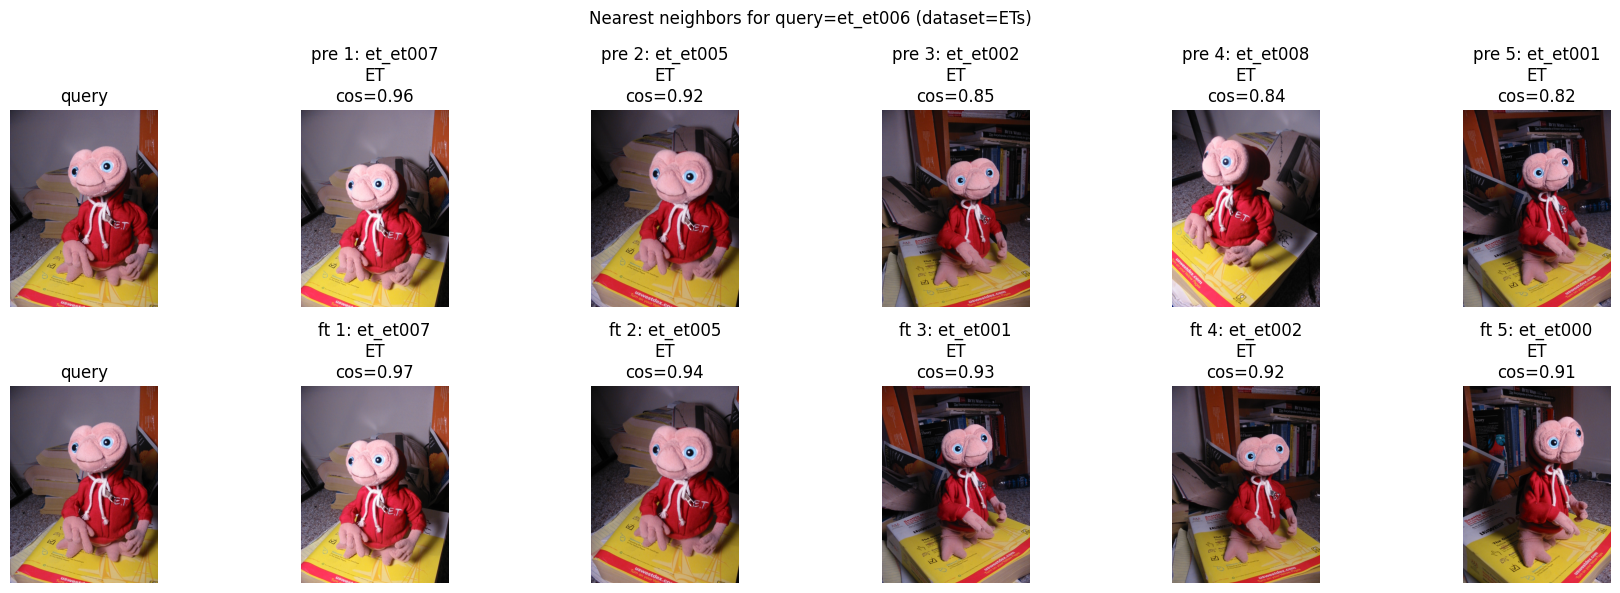

In [9]:
from PIL import Image

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)


def _resolve_path(p: str) -> Path:
    pp = Path(str(p))
    if pp.is_absolute():
        return pp
    return REPO_ROOT / pp


def topk_neighbors(cache_root: Path, *, dataset: str, query_key: str, k: int = 5) -> tuple[str, list[tuple[str, float]]]:
    image_ids, emb, paths = load_cache(cache_root, dataset)
    idx_map = {str(iid): int(i) for i, iid in enumerate(image_ids)}
    q = idx_map[str(query_key)]
    z = _normalize_rows(emb)
    sim = z @ z[q]
    order = np.argsort(-sim)
    neigh = []
    for j in order.tolist():
        if int(j) == int(q):
            continue
        neigh.append((str(image_ids[int(j)]), float(sim[int(j)])))
        if len(neigh) >= int(k):
            break
    q_path = _resolve_path(paths[int(q)])
    return str(q_path), neigh


# Pick a query from one of the top scenes.
query_key = sel_keys[len(sel_keys) // 3] if sel_keys else None
assert query_key is not None, "No images selected for visualization"
query_scene = labels_vis.loc[labels_vis["image_key"] == query_key, "scene"].astype(str).iloc[0]
print("query:", query_key, "scene:", query_scene)

q_path, neigh_pre = topk_neighbors(CACHE_PRETRAINED_TEST, dataset=VIS_DATASET, query_key=query_key, k=5)
_q_path2, neigh_ft = topk_neighbors(CACHE_FINETUNED_TEST, dataset=VIS_DATASET, query_key=query_key, k=5)

scene_of_vis = {str(r.image_key): str(r.scene) for r in labels_vis.itertuples(index=False)}
same_pre = sum(scene_of_vis.get(str(iid)) == str(query_scene) for iid, _s in neigh_pre)
same_ft = sum(scene_of_vis.get(str(iid)) == str(query_scene) for iid, _s in neigh_ft)
print(f"same-scene in top5: pretrained={same_pre}/5  finetuned={same_ft}/5")

if plt is None:
    print("pretrained neighbors:", neigh_pre)
    print("finetuned neighbors:", neigh_ft)
else:
    fig, axes = plt.subplots(2, 6, figsize=(18, 6))
    fig.suptitle(f"Nearest neighbors for query={query_key} (dataset={VIS_DATASET})")

    # Query column
    q_im = Image.open(q_path).convert("RGB")
    for r in [0, 1]:
        axes[r, 0].imshow(q_im)
        axes[r, 0].axis("off")
        axes[r, 0].set_title("query")

    def _show_row(row: int, neigh: list[tuple[str, float]], title_prefix: str, cache_root: Path):
        image_ids, _emb, paths = load_cache(cache_root, VIS_DATASET)
        path_of = {str(iid): _resolve_path(p) for iid, p in zip(image_ids, paths, strict=False)}
        for c, (iid, s) in enumerate(neigh, start=1):
            p = path_of.get(str(iid))
            if p is None or not p.exists():
                axes[row, c].axis("off")
                axes[row, c].set_title(f"{title_prefix}{c}: missing")
                continue
            im = Image.open(p).convert("RGB")
            axes[row, c].imshow(im)
            axes[row, c].axis("off")
            n_scene = scene_of_vis.get(str(iid), "?")
            axes[row, c].set_title(f"{title_prefix}{c}: {iid}\n{n_scene}\ncos={s:.2f}")

    _show_row(0, neigh_pre, "pre ", CACHE_PRETRAINED_TEST)
    _show_row(1, neigh_ft, "ft ", CACHE_FINETUNED_TEST)
    plt.tight_layout()
    plt.show()
